In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd 


In [2]:
df=pd.read_csv("C:/Users/gupta\Documents/GitHub/Last-Mile-Delivery-Delay-Root-Cause-Analysis/data/processed/final_deliveries_clean.csv")

<>:1: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:1: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
C:\Users\gupta\AppData\Local\Temp\ipykernel_13464\1140245213.py:1: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  df=pd.read_csv("C:/Users/gupta\Documents/GitHub/Last-Mile-Delivery-Delay-Root-Cause-Analysis/data/processed/final_deliveries_clean.csv")


C:\Users\gupta\AppData\Local\Temp\ipykernel_11708\1324210087.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='City', y='Delay_Minutes', data=df, palette='Set2')


FileNotFoundError: [Errno 2] No such file or directory: 'outputs/A1_delay_by_city.png'

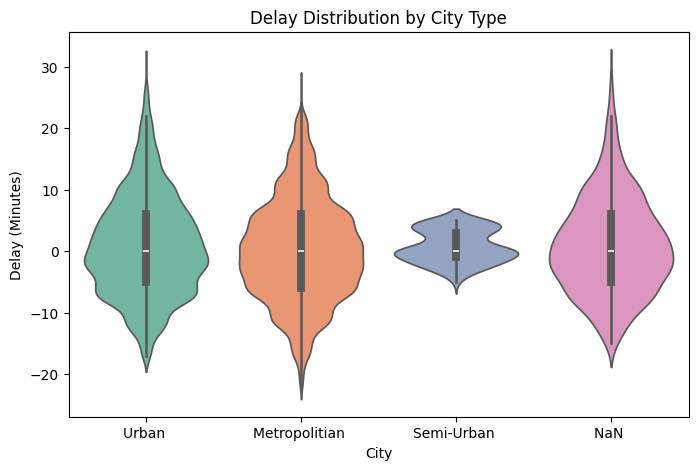

In [ ]:

# ── A1: Delay by City ─────────────────────────────────────
plt.figure(figsize=(8, 5))
sns.violinplot(x='City', y='Delay_Minutes', data=df, palette='Set2')
plt.title('Delay Distribution by City Type')
plt.xlabel('City')
plt.ylabel('Delay (Minutes)')
plt.savefig('outputs/A1_delay_by_city.png', dpi=150)
plt.show()

In [ ]:

# ── Extract Hour and Day from Time_Orderd ─────────────────
df['Time_Orderd'] = pd.to_datetime(df['Time_Orderd'], format='%H:%M:%S', errors='coerce')
df['Hour']    = df['Time_Orderd'].dt.hour
df['DayOfWeek'] = pd.to_datetime(df['Order_Date'], 
                  format='%d-%m-%Y', errors='coerce').dt.day_name()

# ── Check it worked ───────────────────────────────────────
print(df[['Order_Date', 'Time_Orderd', 'Hour', 'DayOfWeek']].head())

   Order_Date         Time_Orderd  Hour DayOfWeek
0  19-03-2022 1900-01-01 11:30:00  11.0  Saturday
1  25-03-2022 1900-01-01 19:45:00  19.0    Friday
2  19-03-2022 1900-01-01 08:30:00   8.0  Saturday
3  05-04-2022 1900-01-01 18:00:00  18.0   Tuesday
4  26-03-2022 1900-01-01 13:30:00  13.0  Saturday


C:\Users\gupta\AppData\Local\Temp\ipykernel_11708\329333298.py:26: UserWarning: Glyph 9200 (\N{ALARM CLOCK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\gupta\AppData\Local\Temp\ipykernel_11708\329333298.py:27: UserWarning: Glyph 9200 (\N{ALARM CLOCK}) missing from font(s) DejaVu Sans.
  plt.savefig('outputs/A2_heatmap_hour_vs_day.png', dpi=150)


FileNotFoundError: [Errno 2] No such file or directory: 'outputs/A2_heatmap_hour_vs_day.png'

C:\Users\gupta\AppData\Roaming\Python\Python314\site-packages\IPython\core\events.py:82: UserWarning: Glyph 9200 (\N{ALARM CLOCK}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\gupta\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9200 (\N{ALARM CLOCK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


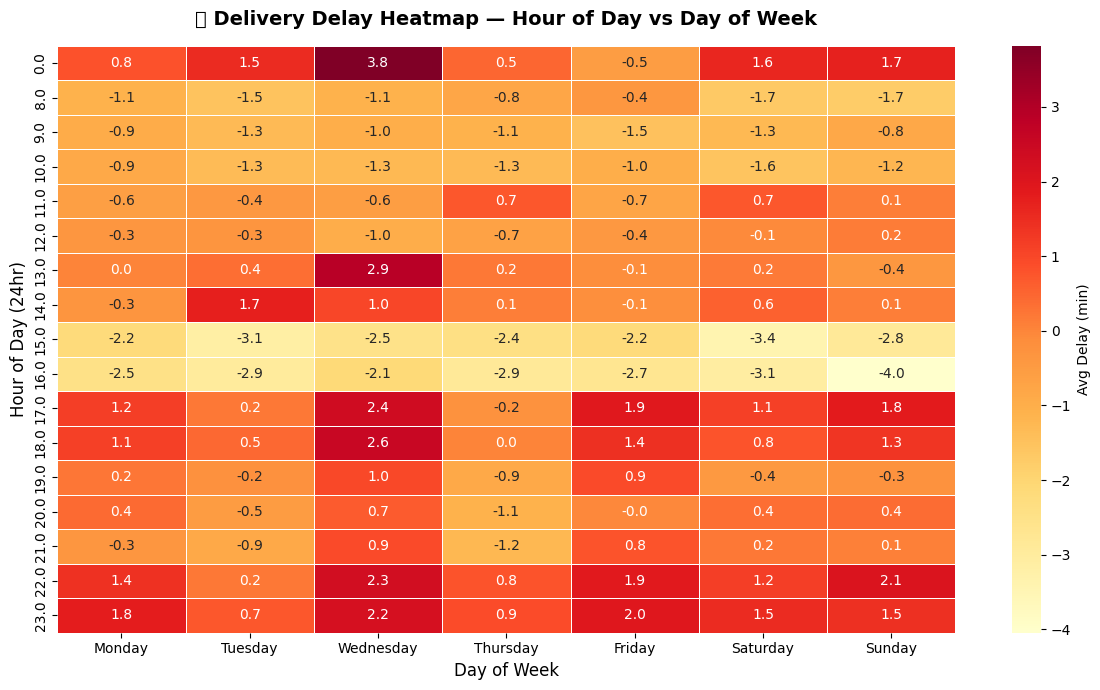

In [ ]:
# ── Pivot table: avg Delay per Hour × Day ─────────────────
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

pivot = df.pivot_table(
    values='Delay_Minutes',
    index='Hour',
    columns='DayOfWeek',
    aggfunc='mean'
)[day_order]   # reorder columns Mon → Sun

# ── Plot ──────────────────────────────────────────────────
plt.figure(figsize=(12, 7))
sns.heatmap(
    pivot,
    cmap='YlOrRd',       # yellow = low delay, red = high delay
    annot=True,
    fmt='.1f',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Avg Delay (min)'}
)
plt.title('⏰ Delivery Delay Heatmap — Hour of Day vs Day of Week', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Day of Week', fontsize=12)
plt.ylabel('Hour of Day (24hr)', fontsize=12)
plt.tight_layout()
plt.savefig('outputs/A2_heatmap_hour_vs_day.png', dpi=150)
plt.show()

## Insight of heatmap
"Delays are not random — they follow a clear structural pattern. The 15:00–16:00 window is the optimal delivery slot (negative delay = early). Wednesday midnight and 13:00 are consistent bottlenecks, suggesting operational issues at the hub mid-week. Late night slots (22:00–23:00) are structurally over-promised across all 7 days."

C:\Users\gupta\AppData\Local\Temp\ipykernel_11708\1753798943.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\gupta\AppData\Local\Temp\ipykernel_11708\1753798943.py:22: UserWarning: Glyph 127783 (\N{CLOUD WITH RAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\gupta\AppData\Local\Temp\ipykernel_11708\1753798943.py:23: UserWarning: Glyph 127783 (\N{CLOUD WITH RAIN}) missing from font(s) DejaVu Sans.
  plt.savefig('outputs/A3_delay_by_weather.png', dpi=150)


FileNotFoundError: [Errno 2] No such file or directory: 'outputs/A3_delay_by_weather.png'

C:\Users\gupta\AppData\Roaming\Python\Python314\site-packages\IPython\core\events.py:82: UserWarning: Glyph 127783 (\N{CLOUD WITH RAIN}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
C:\Users\gupta\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127783 (\N{CLOUD WITH RAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


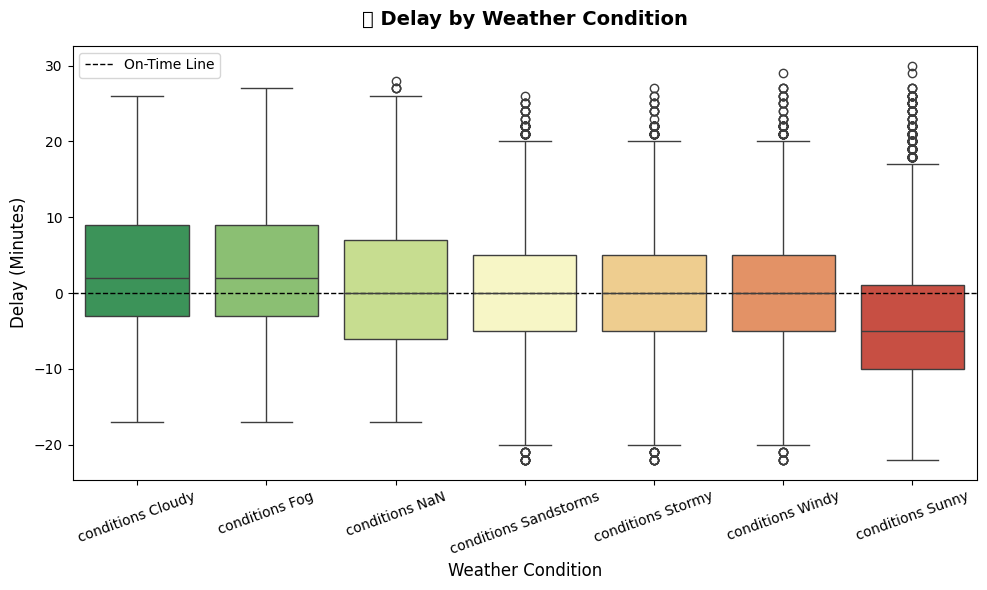

In [ ]:
# ── A3: Delay by Weather Condition ───────────────────────
plt.figure(figsize=(10, 6))

# Get order by median delay (worst to best)
order = df.groupby('Weatherconditions')['Delay_Minutes']\
          .median().sort_values(ascending=False).index

sns.boxplot(
    x='Weatherconditions',
    y='Delay_Minutes',
    data=df,
    order=order,
    palette='RdYlGn_r'   # red = high delay, green = low
)

plt.title('🌧 Delay by Weather Condition', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Weather Condition', fontsize=12)
plt.ylabel('Delay (Minutes)', fontsize=12)
plt.xticks(rotation=20)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1, label='On-Time Line')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/A3_delay_by_weather.png', dpi=150)
plt.show()

### Key Finding: 
Cloudy and Fog are bigger delay drivers than Stormy — likely because fog reduces rider speed and visibility more consistently than sudden storms.

In [ ]:
df['Weatherconditions'] = df['Weatherconditions'].str.replace('conditions ', '', regex=False).str.strip()
print(df['Weatherconditions'].unique())


['Sunny' 'Stormy' 'Sandstorms' 'Cloudy' 'Fog' 'Windy' 'NaN']


In [ ]:
df = df[df['Weatherconditions'] != 'NaN']
df = df.dropna(subset=['Weatherconditions'])

print(df.shape) 

(44977, 27)


In [8]:
# Check what's happening
print(df.groupby('Road_traffic_density')['Time_taken(min)'].mean())
print(df.groupby('Road_traffic_density')['Delay_Minutes'].mean())

Road_traffic_density
High       27.240000
Jam        31.176624
Low        21.266977
Medium     26.699644
NaN        26.542429
Name: Time_taken(min), dtype: float64
Road_traffic_density
High       0.146441
Jam        0.087110
Low        0.462299
Medium     0.633690
NaN        0.935108
Name: Delay_Minutes, dtype: float64


### Traffic Barplot

C:\Users\gupta\AppData\Local\Temp\ipykernel_13464\2673007302.py:5: UserWarning: 
The palette list has fewer values (4) than needed (5) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(
C:\Users\gupta\AppData\Local\Temp\ipykernel_13464\2673007302.py:26: UserWarning: Glyph 128678 (\N{VERTICAL TRAFFIC LIGHT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\gupta\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128678 (\N{VERTICAL TRAFFIC LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


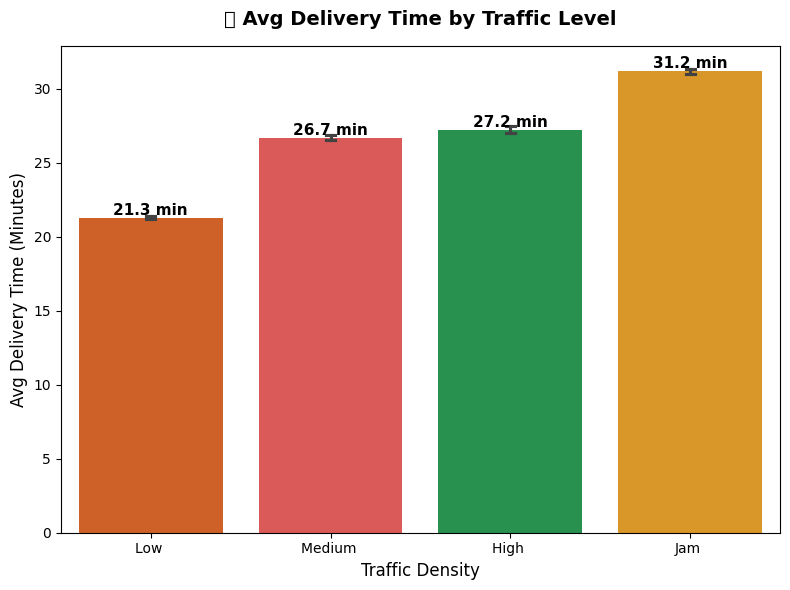

In [ ]:
plt.figure(figsize=(8, 6))

traffic_order = ['Low ', 'Medium ', 'High ', 'Jam ']

sns.barplot(
    x='Road_traffic_density',
    y='Time_taken(min)',          # ← use raw time, not Delay_Minutes
    data=df,
    order=traffic_order,
    hue='Road_traffic_density',
    palette=['#16A34A', '#F59E0B', '#EA580C', '#EF4444'],
    legend=False,
    capsize=0.05
)

# Add value labels on top of each bar
ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f} min',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Avg Delivery Time by Traffic Level', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Traffic Density', fontsize=12)
plt.ylabel('Avg Delivery Time (Minutes)', fontsize=12)
plt.tight_layout()
plt.show()

### Business Finding: 
Jam traffic adds nearly 10 extra minutes per delivery vs low traffic. This directly proves the business should invest in routing AI, not hiring more riders.
